# Exercise 1 — Linear Regression


## Part A: Understanding LR

Imagine we have data from a small restaurant.

For each table, we know:

- the total bill
- the tip left by the customer

We want to predict the tip from the bill using a straight line:

`predicted tip = weight × bill + bias`

Your task is to change `weight` and `bias` until the line fits the data as well as possible.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Sample restaurant data
# x = total bill in dollars
# y = tip in dollars

x = np.array([10, 12, 15, 18, 20, 22, 25, 28, 30, 35, 40, 45])

y = np.array([1.8, 2.0, 2.7, 3.0, 3.6, 3.5, 4.2, 4.8, 5.0, 5.8, 6.5, 7.0])

In [36]:
# You should change only these two numbers
weight = 0.145
bias = 0.5

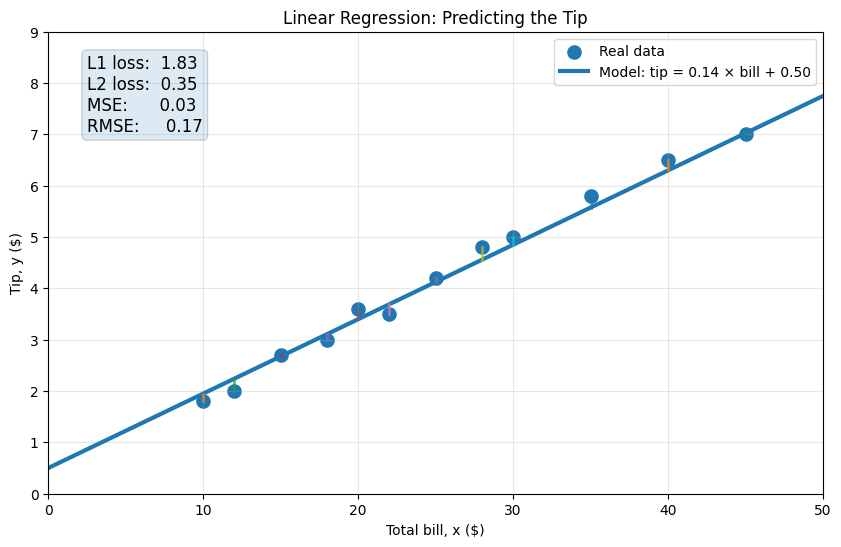

In [37]:
# Predictions
y_pred = weight * x + bias

# Residuals and losses
residuals = y - y_pred

l1 = np.sum(np.abs(residuals))
l2 = np.sum(residuals ** 2)
mse = np.mean(residuals ** 2)
rmse = np.sqrt(mse)

# Plot
plt.figure(figsize=(10, 6))

plt.scatter(x, y, s=90, label="Real data")

# Regression line
x_line = np.linspace(0, 50, 100)
y_line = weight * x_line + bias

plt.plot(
    x_line,
    y_line,
    linewidth=3,
    label=f"Model: tip = {weight:.2f} × bill + {bias:.2f}"
)

# Residual lines
for xi, yi, ypi in zip(x, y, y_pred):
    plt.plot([xi, xi], [yi, ypi], linewidth=2, alpha=0.7)

plt.title("Linear Regression: Predicting the Tip")
plt.xlabel("Total bill, x ($)")
plt.ylabel("Tip, y ($)")

plt.xlim(0, 50)
plt.ylim(0, 9)
plt.grid(True, alpha=0.3)
plt.legend()

loss_text = (
    f"L1 loss:  {l1:.2f}\n"
    f"L2 loss:  {l2:.2f}\n"
    f"MSE:      {mse:.2f}\n"
    f"RMSE:     {rmse:.2f}"
)

plt.text(
    0.05,
    0.95,
    loss_text,
    transform=plt.gca().transAxes,
    verticalalignment="top",
    bbox=dict(boxstyle="round", alpha=0.15),
    fontsize=12
)

plt.show()

### Your task

Change the values of `weight` and `bias`, then rerun the cell.

Try to make the line fit the points as well as possible.

Questions:

1. What is the lowest MSE you can find?
2. Which values of `weight` and `bias` gave you that MSE?
3. What happens to the residual lines when the model improves?
4. What does the `weight` mean in this example?
5. What does the `bias` mean?

Answer:

1. The lowest MSE is 0.03
2. Weight = 0.145 , Bias = 0.5
3. The residual line becomes shorter
4. The weight is the slope of the prediction line
5. The bias is the prediction output when input = 0

In [64]:
# Compute the best linear regression solution automatically

best_weight, best_bias = np.polyfit(x, y, 1)

y_best = best_weight * x + best_bias
best_mse = np.mean((y - y_best) ** 2)
best_rmse = np.sqrt(best_mse)

print(f"Best weight: {best_weight:.3f}")
print(f"Best bias:   {best_bias:.3f}")
print(f"Best MSE:    {best_mse:.3f}")
print(f"Best RMSE:   {best_rmse:.3f}")

Best weight: 0.154
Best bias:   0.315
Best MSE:    0.019
Best RMSE:   0.139


## Part B: Use a real dataset

In the previous exercise, we used (unexisting) sample data.

Now choose one real dataset and repeat the same process:

1. Load the dataset.
2. Choose one numerical column as `x`.
3. Choose one numerical column as `y`.
4. Fit a line manually by changing `weight` and `bias`.
5. Compute the residuals, MSE, and RMSE.
6. Compare your manual line with the best line found by Python.

The model is always:

`y_pred = weight * x + bias`

### Option 1 — Student performance dataset from Hugging Face

This one is probably closest to your idea:

> Can we predict exam score from study hours?

The Hugging Face dataset `krishal07/student-performance` includes columns such as `StudyHours`, `TestScore_Math`, `TestScore_Reading`, `TestScore_Science`, `GPA`, and `AttendanceRate`.  

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset

dataset = load_dataset("krishal07/student-performance", split="train")

df = dataset.to_pandas()
df.head()

,Age,Grade,Gender,Race,SES_Quartile,ParentalEducation,SchoolType,Locale,TestScore_Math,TestScore_Reading,...,GPA,AttendanceRate,StudyHours,InternetAccess,Extracurricular,PartTimeJob,ParentSupport,Romantic,FreeTime,GoOut
0,17,12,Female,White,3,HS,Public,Suburban,70.258235,79.665185,...,2.743879,0.906809,1.089243,1,1,0,0,0,2,2
1,18,12,Female,White,2,HS,Public,Suburban,67.876546,59.611505,...,2.587700,0.843739,0.879911,1,1,0,1,0,5,2
2,16,11,Female,White,2,HS,Public,City,62.070623,70.577443,...,2.426294,0.850923,1.003442,1,1,0,1,1,5,1
3,14,9,Female,White,4,Bachelors+,Public,Town,79.909312,82.924450,...,3.558240,0.946786,1.814810,1,1,0,1,0,4,2
4,16,11,Female,Two-or-more,4,SomeCollege,Public,Rural,90.562294,95.352336,...,3.896884,0.988036,1.157241,1,1,0,0,0,3,4


In [4]:
# Question:
# Can we predict math test score from study hours?

x = df["StudyHours"].to_numpy()
y = df["TestScore_Math"].to_numpy()

print("Number of students:", len(x))
print("First 5 study-hour values:", x[:5])
print("First 5 math scores:", y[:5])

Number of students: 8000774
First 5 study-hour values: [1.08924319 0.87991072 1.00344238 1.81481015 1.15724067]
First 5 math scores: [70.25823548 67.87654582 62.07062326 79.90931215 90.56229366]


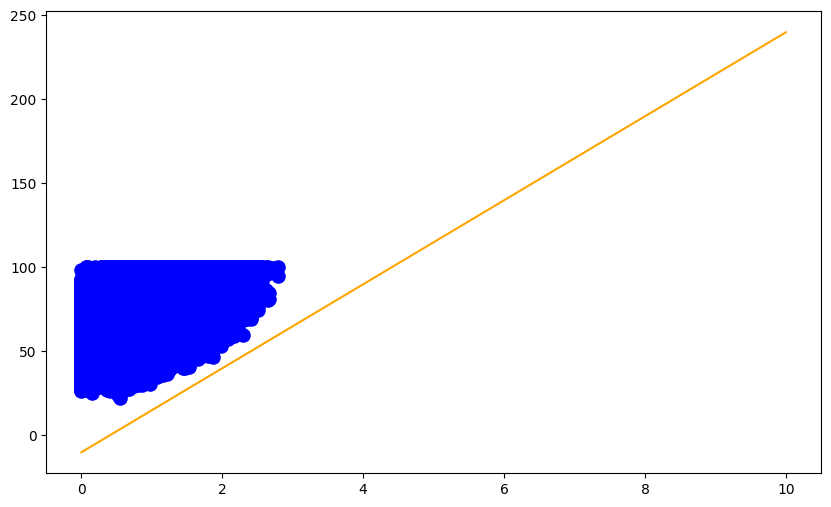

In [10]:
weight = 25
bias = -10

predict = weight * x + bias
residual = y - predict

plt.figure(figsize=(10, 6))

x_line = np.linspace(0, 10, 100)
y_line = weight * x_line + bias

plt.plot(x_line, y_line, label="Model: score = weight × hours + bias", color="orange")
plt.scatter(x, y, s=90, label="Student data", color="blue")
plt.show()

#### Questions

1. Does more study time usually mean a higher test score?
2. Is the relationship perfectly linear?
3. Are there students with high study time but lower scores?
4. What other variables might help predict exam score?

#### Answer

1. No, some students showed to have high test score with low study time
2. The relationship is not linear
3. There is no such student apparent in the dataset
4. Many other features may affect the exam score such as attendance rate, extracurricular, internet access...